In [1]:
import pandas as pd
all_data = pd.read_csv("jigsaw_all.csv")

In [2]:
new_data = all_data[['id', 'comment_text', 'created_date', 'parent_id', 'article_id', 'toxicity', 'toxicity_annotator_count']]
# remove comments that are replies to other comments
print(f"There are {len(new_data)} comments in the dataset, and {len(new_data[new_data['parent_id'].isna()])} of them are not replies to other comments.")
new_data = new_data[new_data['parent_id'].isna()]
new_data['comment_text'] = new_data['comment_text'].str.replace("\n", " ")

There are 1999516 comments in the dataset, and 864807 of them are not replies to other comments.


In [3]:
# filter out too short comments
new_data['comment_text'] = new_data['comment_text'].str.strip()
new_data["comment_len"] = new_data["comment_text"].str.len()
new_data = new_data[new_data["comment_len"] >= 10]

# filter out too short comments in terms of their words
new_data["comment_word_count"] = new_data["comment_text"].str.split().str.len()
new_data = new_data[new_data['comment_word_count'] >= 3]

In [4]:
# remove too long comments
new_data = new_data[new_data["comment_word_count"] <= 50]

In [5]:
new_data["toxic"] = new_data["toxicity"] > 0.5
article_stat = new_data.groupby("article_id").agg({"toxic": "sum", "id": "count"})
article_stat = article_stat.rename(columns={"toxic": "toxic_comment", "id": "comment_count"})
article_stat

,toxic_comment,comment_count
article_id,,
2006,2,7
2316,0,1
2384,0,1
2672,0,1
4364,0,1
...,...,...
399531,0,2
399538,0,1
399539,0,1


In [6]:
article_threshold = 100
filtered_article = article_stat[(article_stat["comment_count"] >= article_threshold) & (article_stat["toxic_comment"] > 10)]
# see how many articles and comments are left
print(f"left {len(filtered_article)} articles and {filtered_article['comment_count'].sum()} comments")

# what are left comments, merge with all_data
left_comments = new_data[new_data['article_id'].isin(filtered_article.index)]
left_comments = left_comments.sort_values(by=['article_id'])

left 53 articles and 8581 comments


In [7]:
left_comments = left_comments.rename(columns={"comment_text": "comment"})
left_comments = left_comments[["article_id", "toxicity", "comment"]]
# store left_comments as a json
left_comments.to_json("jigsaw_sampled.json", orient="records", lines=True)

### read and create a balanced dataset for testing

In [6]:
import json
import pandas as pd
def clean_jigsaw_comment(comment):
    text = comment["comment"].strip()
    # escape double quotes
    text = text.replace('"', '').replace("\\", "").replace("`", "")
    if len(text) == 0:
        return None
    return {"text": text, "score": comment["toxicity"]}

dataset = []
dataset_path = "collected_datasets/jigsaw_sampled.json"

with open(dataset_path) as f:
    for line in f:
        comment = line.strip()
        comment = clean_jigsaw_comment(json.loads(comment))
        if comment is not None:
            dataset.append(comment)
dataset = pd.DataFrame(dataset)

In [7]:
# create balanced datasets
dataset = dataset.sample(frac=1).reset_index(drop=True)

# sample the same number of toxic and non-toxic comments, note that the number of toxic comments is less than the number of non-toxic comments
toxic_comments = dataset[dataset["score"] > 0.5]
non_toxic_comments = dataset[dataset["score"] <= 0.5]

print(f"the length of the non-toxic comments: {len(non_toxic_comments)}; the length of the toxic comments: {len(toxic_comments)}")
non_toxic_comments = non_toxic_comments.sample(n=1000).reset_index(drop=True)
toxic_comments = toxic_comments.sample(n=1000).reset_index(drop=True)
balanced_dataset = pd.concat([toxic_comments, non_toxic_comments]).sample(frac=1).reset_index(drop=True)
print("describe the balanced dataset:", balanced_dataset["score"].describe())

the length of the non-toxic comments: 7272; the length of the toxic comments: 1309
describe the balanced dataset: count    2000.000000
mean        0.409787
std         0.346373
min         0.000000
25%         0.000000
50%         0.503333
75%         0.716091
max         1.000000
Name: score, dtype: float64


In [31]:
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sentence_transformers import SentenceTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import random
import os, sys

In [9]:
def calculate_algorithm_metrics(y, y_pred):
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    
    
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    # Calculate FNR and FPR
    fnr = fn / (fn + tp)  # False Negative Rate
    fpr = fp / (fp + tn)  # False Positive Rate

    return {
        "accuracy": accuracy, 
        "precision": precision, 
        "recall": recall,
        "fnr": fnr,
        "fpr": fpr
    }

In [10]:
class ML_Filter:
    def __init__(self, model_name, rng = random.Random(3141)):
        self.model_name = model_name
        self.model = GaussianNB()
        self.pipe = None
        self.embeddings = SentenceTransformer('all-MiniLM-L6-v2') # Model for embeddings

    def train_model(self, X, y):
        X_train, y_train = X, y
        X_train = self.embeddings.encode(X_train)

        # Train the model
        if self.pipe is None:
            self.pipe = Pipeline([
                ('scaler', StandardScaler(with_mean = False)),
                (self.model_name, self.model)
            ])
            self.pipe.fit(X_train, y_train)
        

    def test_model(self, X, y):
        X_test, y_test = X, y
        X_test = self.embeddings.encode(X_test)
        y_pred = self.pipe.predict(X_test)
        
        performance = calculate_algorithm_metrics(y_test, y_pred)
        return performance
    
    def predict_proba(self, X):
        X = self.embeddings.encode(X)
        return self.pipe.predict_proba(X)

In [11]:
balanced_dataset["label"] = balanced_dataset["score"].apply(lambda x: 1 if x > 0.5 else 0)
X = [text for text in balanced_dataset["text"]]
y = [label for label in balanced_dataset["label"]]

In [18]:
len(X), len(y)

(2000, 2000)

### test how many examples are needed for groundtruh

In [44]:
import dis

from django import conf, test
from sympy import per


def get_performance(train_size, test_size):

    train_X, test_X, train_y, test_y = train_test_split(X, y, train_size=train_size, test_size=test_size, shuffle=True, random_state=None)
    model = ML_Filter("GaussianNB")
    model.train_model(train_X, train_y)
    performance = model.test_model(test_X, test_y)
    return performance

def test_performance(train_size, test_size):
    # call the same function 10 times and calculate its average and variance
    performance = []
    for i in range(30):
        performance.append(get_performance(train_size, test_size))
    performance = pd.DataFrame(performance)
    
    # print out mean, std, and min, and max
    mean = performance.mean()
    sem = performance.sem()
    df = len(performance) - 1
    confidence = 0.95
    ci = stats.t.interval(confidence, df, loc=mean, scale=sem)
    performance = performance.describe()
    performance.loc["lower", :] = ci[0]
    performance.loc["upper", :] = ci[1]
    return performance.loc[["mean", "lower", "upper"], :]


In [46]:
test_performance(150, 100)

,accuracy,precision,recall,fnr,fpr
mean,0.685000,0.677872,0.697090,0.302910,0.319863
lower,0.644639,0.629077,0.633498,0.239317,0.261214
upper,0.725361,0.726667,0.760683,0.366502,0.378512


In [47]:
test_performance(150, 50)

,accuracy,precision,recall,fnr,fpr
mean,0.690000,0.718166,0.664614,0.335386,0.277878
lower,0.631107,0.651535,0.574690,0.245462,0.192118
upper,0.748893,0.784796,0.754538,0.425310,0.363637


In [48]:
test_performance(150, 200)

,accuracy,precision,recall,fnr,fpr
mean,0.6745,0.693780,0.654784,0.345216,0.305207
lower,0.6483,0.658111,0.599774,0.290206,0.266065
upper,0.7007,0.729450,0.709794,0.400226,0.344349


In [49]:
test_performance(100, 200)

,accuracy,precision,recall,fnr,fpr
mean,0.670000,0.662819,0.673766,0.326234,0.330968
lower,0.639231,0.625908,0.597083,0.249552,0.272019
upper,0.700769,0.699731,0.750448,0.402917,0.389918


In [51]:
test_performance(50, 100)

,accuracy,precision,recall,fnr,fpr
mean,0.626000,0.669692,0.505793,0.494207,0.247950
lower,0.572553,0.599882,0.373453,0.361868,0.162867
upper,0.679447,0.739502,0.638132,0.626547,0.333032


### test the use of naive bayes in active learning

In [62]:
ITERATION = 10
BATCH_SIZE = 20

# create a train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
def active_learning(X_train, X_test, y_train, y_test, active_learning=True):
    print(f"batch size: {BATCH_SIZE}; iteration: {ITERATION}")
    perf_list = []
    # create the initial examples
    local_random = random.Random()  # This creates a local instance of a random number generator
    local_random.seed(42)  # Set the seed for this instance
    
    initial_seeds = local_random.sample(range(len(X_train)), BATCH_SIZE)
    X_labeled = [X_train[i] for i in initial_seeds]
    y_labeled = [y_train[i] for i in initial_seeds]

    X_unlabeled = [X_train[i] for i in range(len(X_train)) if i not in initial_seeds]
    y_unlabeled = [y_train[i] for i in range(len(y_train)) if i not in initial_seeds]


    for epoch in range(ITERATION):
        # print(f"epoch {epoch}")
        
        # print(f"labeled samples: {len(X_labeled)}; unlabeled samples: {len(X_train)}")
        # print(f"labeled toxic samples: {sum(y_labeled)}; labeled non-toxic samples: {len(y_labeled) - sum(y_labeled)}")

        model = ML_Filter("GaussianNB")
        model.train_model(X_labeled, y_labeled)

        # calculate the accuracy
        performance = model.test_model(X_test, y_test)
        perf_list.append(performance["accuracy"])

        if active_learning:
            # determine the next batch of samples
            X_unlabeled_prob = model.predict_proba(X_unlabeled)

            uncertainties = [ 1 - abs(prob[0] - prob[1]) for prob in X_unlabeled_prob]
            # get the indices of the most uncertain samples
            selected_indices = sorted(range(len(uncertainties)), key=lambda i: uncertainties[i], reverse=True)[:BATCH_SIZE]
        else:
            selected_indices = random.sample(range(len(X_unlabeled)), BATCH_SIZE)

        
        X_labeled.extend([X_unlabeled[i] for i in selected_indices])
        y_labeled.extend([y_unlabeled[i] for i in selected_indices])
        X_unlabeled = [X_unlabeled[i] for i in range(len(X_unlabeled)) if i not in selected_indices]
        y_unlabeled = [y_unlabeled[i] for i in range(len(y_unlabeled)) if i not in selected_indices]

    return perf_list

def test_params(batch_size, iteration):
    global ITERATION, BATCH_SIZE
    ITERATION = iteration
    BATCH_SIZE = batch_size
    
    uncertainty_acc_list = active_learning(X_train, X_test, y_train, y_test)
    random_acc_list = active_learning(X_train, X_test, y_train, y_test, active_learning=False)

    # draw the figure of how accuracy changes across iterations
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    num_examples = [BATCH_SIZE * (i + 1) for i in range(len(uncertainty_acc_list))]

    plt.plot(num_examples, uncertainty_acc_list, label="Uncertainty Sampling", linewidth=2)
    plt.plot(num_examples, random_acc_list, label="Random Sampling", linewidth=2)
    plt.xticks(num_examples) 
    plt.xlabel("Number of Examples")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Across Number of Examples")
    plt.legend()
    plt.ylim(0.50, 0.80)
    plt.show()


batch size: 20; iteration: 10
batch size: 20; iteration: 10


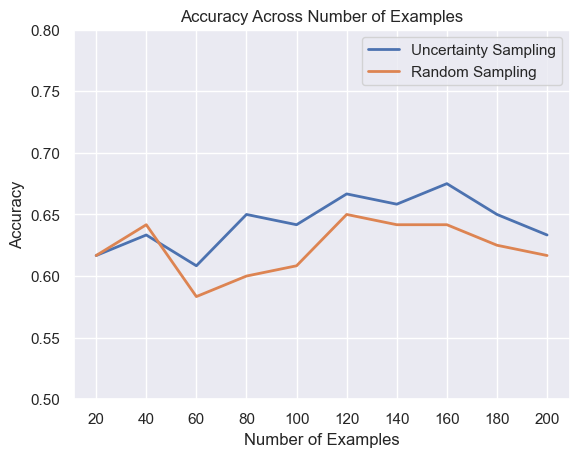

In [63]:
test_params(20, 10)


batch size: 30; iteration: 10
batch size: 30; iteration: 10


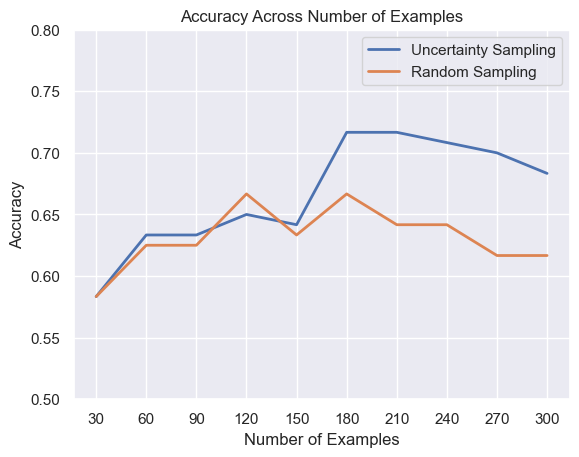

In [64]:
test_params(30, 10)

batch size: 30; iteration: 10
batch size: 30; iteration: 10


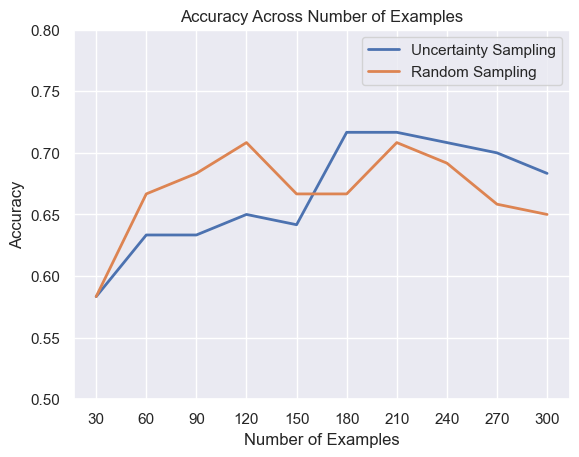

In [65]:
test_params(30, 10)

batch size: 10; iteration: 20
batch size: 10; iteration: 20


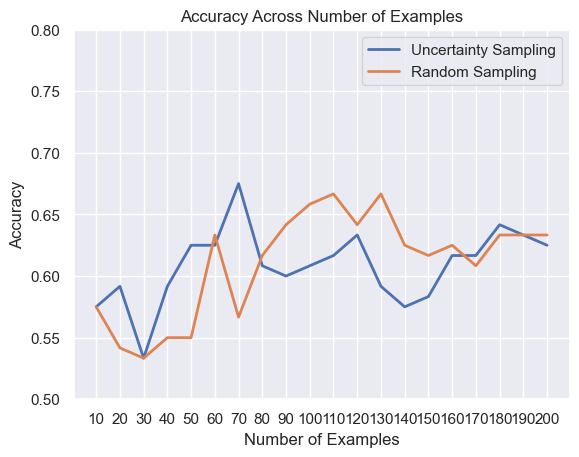

In [67]:
test_params(10, 20)